# Gan Wen Hao Isaac: All Model Comparison Evaluation

### In this Notebook, we will compare all 9 models that will be deployed into our application to evaluate them and idenifty their strengths, weaknesses and key features.

### Loading all models and data 

In [ ]:
import pandas as pd
import nltk
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import TFBertModel, TFBertForSequenceClassification, create_optimizer
from tensorflow.keras.models import load_model
from lime.lime_text import LimeTextExplainer
import tensorflow as tf
from tensorflow.keras.utils import register_keras_serializable

C:\Users\isaac\anaconda3\envs\py310\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [ ]:
import joblib

# Load the model using joblib
LR = joblib.load("logistic_regression_comp_4.pkl")
NB = joblib.load("naive_bayes_comp_4.pkl")
RF = joblib.load("random_forest_comp_2.pkl")
SVM = joblib.load("svm_model_comp_1.pkl")

In [ ]:
import pickle

tfidf_vectorizer = joblib.load("tfidf_vectorizer_Notebook.pkl")
with open('LSTMs-tokenizer.pkl', 'rb') as handle:
    lstm_tokenizer = pickle.load(handle)

with open('BERTs-tokenizer.pkl', 'rb') as handle:
    bert_tokenizer = pickle.load(handle)


In [ ]:
from transformers import BertTokenizer, TFBertModel, TFBertForSequenceClassification
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input

LSTM = load_model("lstm_fixed.keras", compile=False)
CNN_LSTM = load_model("cnn_lstm_fixed.keras", compile=False)

BERT = load_model("bert_redo.keras",
                    custom_objects={'TFBertForSequenceClassification': TFBertForSequenceClassification}, 
                    compile=False)

BERT_LSTM = load_model("bert_LSTM_FINAL.keras",
                        custom_objects={'TFBertModel': TFBertModel},
                        compile=False)

BIGRU = load_model("bigru_redo.keras", compile=False)

In [ ]:
# PREPROCESSING FOR Traditional Models
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))

# Function to preprocess text with lemmatization
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.lower()  # Lowercase text
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'\[.*?\]', '', text)  # Remove brackets
    text = re.sub(r'\W+', ' ', text)  # Remove special characters
    text = re.sub(r'\d+', '', text)  # Remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = " ".join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    return text


# Combine fake and real news into a single dataframe
fake_news = pd.read_csv('fake_cleaned.csv')
real_news = pd.read_csv('true_cleaned.csv')

fake_news['label'] = 0  # 0 for fake
real_news['label'] = 1  # 1 for real
data = pd.concat([fake_news, real_news], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
simple_data['text'] = data['text'].apply(preprocess_text)

X = simple_data['text']
y = simple_data['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\isaac\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### Metrics Evalution

In [ ]:
from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        classification_report, confusion_matrix, roc_curve, auc
)

y_pred_lr = LR.predict(X_test_tfidf)
y_pred_nb = NB.predict(X_test_tfidf)
y_pred_svm = SVM.predict(X_test_tfidf)
y_pred_rf = RF.predict(X_test_tfidf)

# Evaluate Logistic Regression
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

# Evaluate Naive Bayes
print("\nNaive Bayes Performance:")
print(classification_report(y_test, y_pred_nb))

print("Support Vector Machine Performance:")
print(classification_report(y_test, y_pred_svm))

# Evaluate Naive Bayes
print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4592
           1       0.98      0.99      0.99      4220

    accuracy                           0.99      8812
   macro avg       0.99      0.99      0.99      8812
weighted avg       0.99      0.99      0.99      8812


Naive Bayes Performance:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4592
           1       0.94      0.95      0.94      4220

    accuracy                           0.95      8812
   macro avg       0.95      0.95      0.95      8812
weighted avg       0.95      0.95      0.95      8812

Support Vector Machine Performance:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4592
           1       0.99      1.00      0.99      4220

    accuracy                           0.99      8812
   macro avg       0.99      0.99

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test_tfidf, y_test):
    y_pred = model.predict(X_test_tfidf)
    if hasattr(model, "predict_proba"):  # For probabilistic models like LR, NB, RF
        y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_pred_proba = y_pred  
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_pred_proba),
    }


In [ ]:
models = {
    "Logistic Regression": LR,
    "Naive Bayes": NB,
    "Random Forest": RF,
    "SVM": SVM,
}

results = {name: evaluate_model(model, X_test_tfidf, y_test) for name, model in models.items()}


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)


           Logistic Regression  Naive Bayes  Random Forest       SVM
Accuracy              0.988652     0.946096       0.998525  0.994326
Precision             0.984250     0.938627       0.997634  0.992210
Recall                0.992180     0.949526       0.999289  0.995972
F1-score              0.988199     0.944045       0.998461  0.994087
AUC-ROC               0.999268     0.986905       0.999900  0.999776


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
data['text'] = data['text'].astype(str)
# texts = data['text'].values
# labels = data['label'].values

max_words = 10000
max_len = 200

sequences = lstm_tokenizer.texts_to_sequences(data['text'])
X_LSTM = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
Y_LSTM = data["label"].values

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(X_LSTM, Y_LSTM, test_size=0.2, random_state=42, stratify=y)

from sklearn.metrics import classification_report
import numpy as np

def evaluate_model_DL(model, X_test, y_test):
    """
    Evaluate deep learning models and return comprehensive metrics.
    
    Args:
        model: Trained model
        X_test: Test features
        y_test: True labels (1D array or 2D one-hot encoded)
        
    Returns:
        Dictionary containing:
        - Accuracy
        - Precision
        - Recall 
        - F1-score
        - AUC-ROC
    """
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    y_prob = y_pred_proba.flatten()
    
    # Ensure y_test is 1D array
    if y_test.ndim > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)
    

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else float('nan')
    }
    
 
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    return metrics

In [ ]:
models_DL = {
    "LSTM": LSTM,
    "CNN-LSTM": CNN_LSTM,
    "Bi-GRU": BIGRU
}

results_DL = {name: evaluate_model_DL(model, X_test_LSTM, y_test_LSTM) for name, model in models_DL.items()}


276/276 [==============================] - 65s 236ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      4470
           1       0.95      1.00      0.97      4342

    accuracy                           0.97      8812
   macro avg       0.97      0.97      0.97      8812
weighted avg       0.97      0.97      0.97      8812

276/276 [==============================] - 1s 5ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4470
           1       1.00      1.00      1.00      4342

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812

276/276 [==============================] - 4s 15ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4470

In [ ]:
results_DL_df = pd.DataFrame.from_dict(results_DL)
print(results_DL_df)

               LSTM  CNN-LSTM    Bi-GRU
Accuracy   0.972424  0.999887  0.988879
Precision  0.947001  0.999770  0.998825
Recall     1.000000  1.000000  0.978581
F1-score   0.972779  0.999885  0.988599
AUC-ROC    0.999999  1.000000  0.999371


In [ ]:
train_indices, test_indices = train_test_split(data.index, test_size=0.2, random_state=42, stratify=labels)

def encode_texts(texts):
    return bert_tokenizer(texts.tolist(), padding=True, truncation=True, max_length=256, return_tensors='tf')

X_train_texts = data.loc[train_indices, 'text']
X_test_texts = data.loc[test_indices, 'text']
y_train_BERT, y_test_BERT = labels[train_indices], labels[test_indices]

X_train_bert = encode_texts(X_train_texts)
X_test_bert = encode_texts(X_test_texts)

In [ ]:
bert_metrics = evaluate_model_DL(BERT, X_test_bert, y_test_BERT, bert=True)
bert_lstm_metrics = evaluate_model_DL(BERT_LSTM, X_test_bert, y_test_BERT, bert_lstm=True)

266/266 [==============================] - 45s 157ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4242
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8484
   macro avg       1.00      1.00      1.00      8484
weighted avg       1.00      1.00      1.00      8484



C:\Users\isaac\anaconda3\envs\py310\lib\site-packages\keras\engine\functional.py:637: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


266/266 [==============================] - 52s 183ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4242
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8484
   macro avg       1.00      1.00      1.00      8484
weighted avg       1.00      1.00      1.00      8484



In [ ]:
results_df_bert = pd.DataFrame({
    'BERT': bert_metrics,
    'BERT-LSTM': bert_lstm_metrics
})

print(results_df_bert)

               BERT  BERT-LSTM
Accuracy   0.999882        1.0
Precision  1.000000        1.0
Recall     0.999764        1.0
F1-score   0.999882        1.0
AUC-ROC    0.999988        1.0


In [ ]:
print(df_results)
print(results_DL_df)
print(results_df_bert)

           Logistic Regression  Naive Bayes  Random Forest       SVM
Accuracy              0.988652     0.946096       0.998525  0.994326
Precision             0.984250     0.938627       0.997634  0.992210
Recall                0.992180     0.949526       0.999289  0.995972
F1-score              0.988199     0.944045       0.998461  0.994087
AUC-ROC               0.999268     0.986905       0.999900  0.999776
               LSTM  CNN-LSTM    Bi-GRU
Accuracy   0.965048  0.998979  0.989106
Precision  0.932658  0.999056  0.999518
Recall     0.999528  0.998821  0.977830
F1-score   0.964936  0.998939  0.988555
AUC-ROC    0.999810  0.999963  0.999130
               BERT  BERT-LSTM
Accuracy   0.999882        1.0
Precision  1.000000        1.0
Recall     0.999764        1.0
F1-score   0.999882        1.0
AUC-ROC    0.999988        1.0


In [ ]:
# Combine all DataFrames horizontally
combined_df = pd.concat([
    df_results,          # Traditional ML models
    results_DL_df,       # Deep Learning models
    results_df_bert      # BERT models
], axis=1)

# Reorder columns if desired (group related models)
column_order = [
    'Logistic Regression', 'Naive Bayes', 'Random Forest', 'SVM',  # ML
    'LSTM', 'CNN-LSTM', 'Bi-GRU',                                 # DL
    'BERT', 'BERT-LSTM'                                           # BERT
]
combined_df = combined_df[column_order]

# Format and display with improved styling
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

print("\nModel Performance Comparison:")
display(combined_df.style
       .apply(highlight_max)
       .background_gradient(cmap='Blues', vmin=0.85, vmax=1.0)
       .format("{:.3f}")
       .set_caption("Comprehensive Model Evaluation (All Metrics)"))


Model Performance Comparison:


,Logistic Regression,Naive Bayes,Random Forest,SVM,LSTM,CNN-LSTM,Bi-GRU,BERT,BERT-LSTM
Accuracy,0.989,0.946,0.999,0.994,0.972,1.000,0.989,1.000,1.000
Precision,0.984,0.939,0.998,0.992,0.947,1.000,0.999,1.000,1.000
Recall,0.992,0.950,0.999,0.996,1.000,1.000,0.979,1.000,1.000
F1-score,0.988,0.944,0.998,0.994,0.973,1.000,0.989,1.000,1.000
AUC-ROC,0.999,0.987,1.000,1.000,1.000,1.000,0.999,1.000,1.000


#### The comparison reveals that BERT-based models (BERT and BERT-LSTM) achieve perfect or near-perfect scores across all metrics, significantly outperforming traditional machine learning and other deep learning approaches. 

#### The Random Forest classifier shows strong performance among traditional ML models, nearly matching BERT in accuracy (0.999 vs. 1.000), while LSTM trails behind with lower precision (0.933) despite perfect recall (1.000), suggesting potential over-sensitivity. Notably, all models excel in AUC-ROC (≥0.987), indicating robust ranking capability, but BERT variants demonstrate complete dominance in classification tasks. 


#### The results suggest that transformer-based architectures are superior for this specific task, though Random Forest remains competitive for scenarios where simpler models are preferred. The perfect scores of BERT-LSTM highlight the potential benefits of combining attention mechanisms with sequential processing.


#### With this information in mind, we expect the BERT models to capture user input more easily than the other models.

### Confusion Matrixes Display:

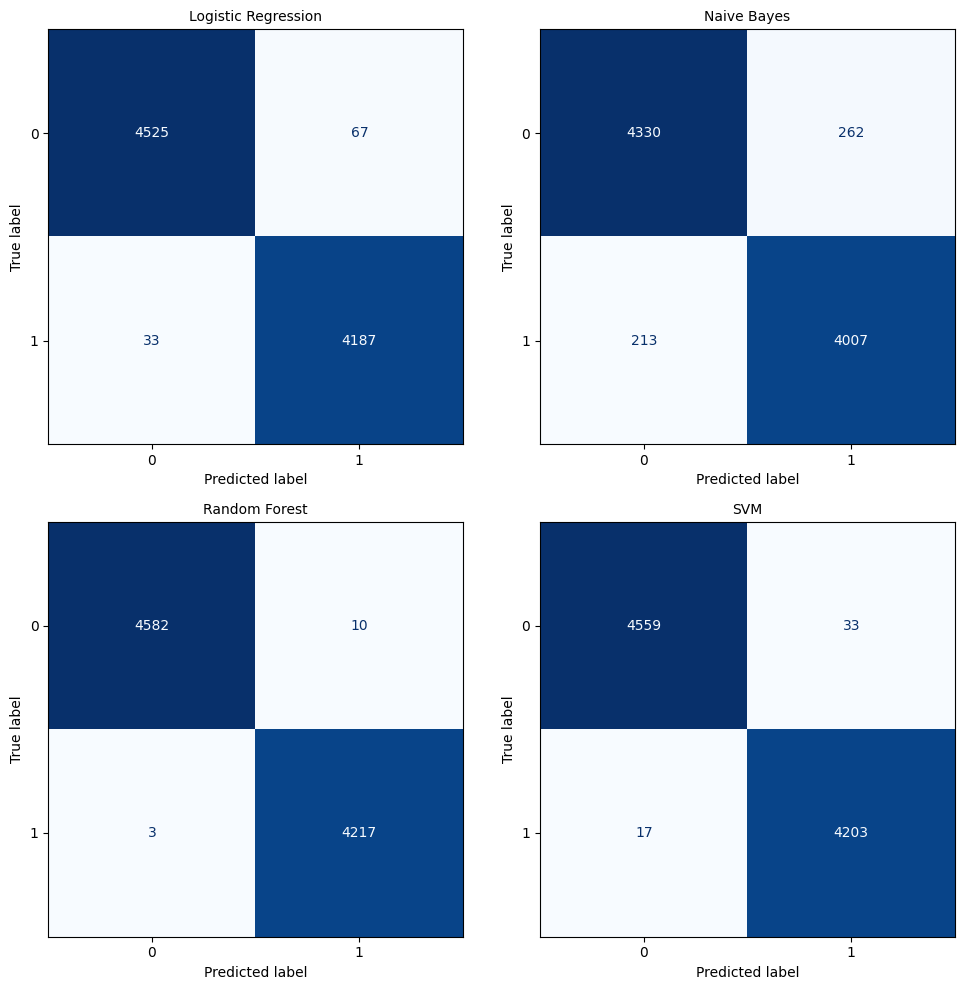

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# List all models with their names and data formats
models = [
    ("Logistic Regression", LR, X_test_tfidf, False),
    ("Naive Bayes", NB, X_test_tfidf, False),
    ("Random Forest", RF, X_test_tfidf, False),
    ("SVM", SVM, X_test_tfidf, False),
]

# Create a 3x4 grid (adjust based on number of models)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for idx, (name, model, X_test, is_bert) in enumerate(models):
    # Get predictions
    if is_bert:
        y_pred = (model.predict([X_test['input_ids'], X_test['attention_mask']]) > 0.5).astype(int)
    else:
        y_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred,
        ax=axes[idx],
        colorbar=False,
        cmap='Blues'
    )
    axes[idx].set_title(name, fontsize=10)
    axes[idx].grid(False)

# Hide empty subplots (if any)
for idx in range(len(models), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def evaluate_model(model, X_test, y_test, title, bert=False):
    if bert:
        preds = (model.predict((X_test['input_ids'], X_test['attention_mask'])) > 0.5).astype('int32')
    else:
        preds = (model.predict(X_test) > 0.5).astype('int32')

    cm = confusion_matrix(y_test, preds)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

276/276 [==============================] - 65s 235ms/step


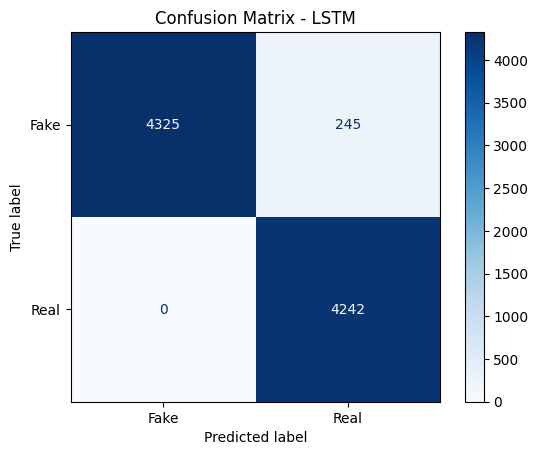

276/276 [==============================] - 1s 5ms/step


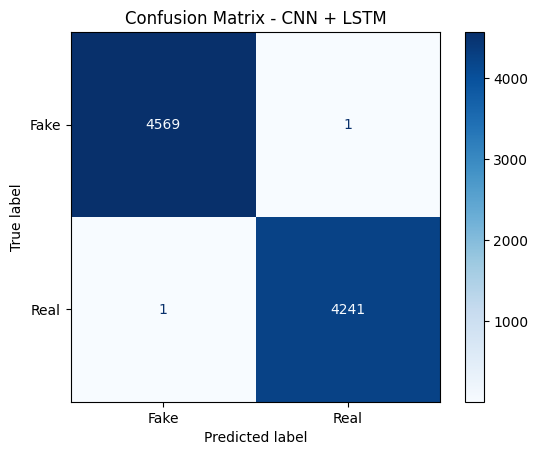

276/276 [==============================] - 4s 16ms/step


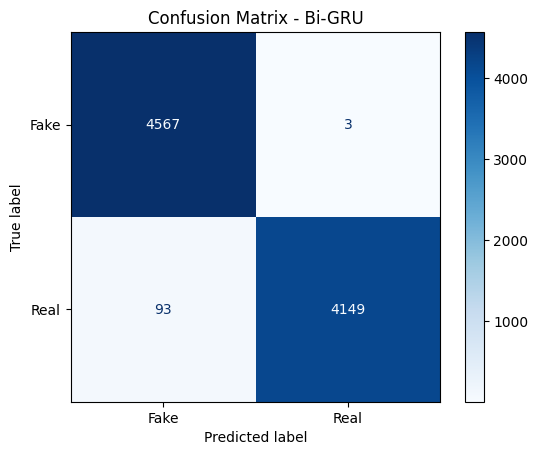

In [ ]:
evaluate_model(LSTM, X_test_LSTM, y_test_LSTM, "LSTM")
evaluate_model(CNN_LSTM, X_test_LSTM, y_test_LSTM, "CNN + LSTM")
evaluate_model(BIGRU, X_test_LSTM, y_test_LSTM, "Bi-GRU")

266/266 [==============================] - 43s 160ms/step


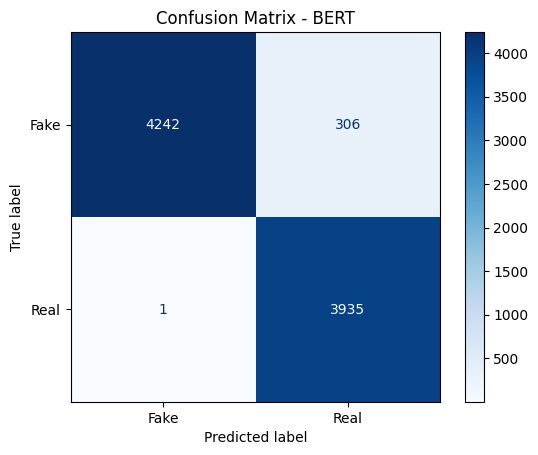

In [ ]:
evaluate_model(BERT, X_test_bert, y_test_BERT, "BERT", bert=True)

266/266 [==============================] - 50s 187ms/step


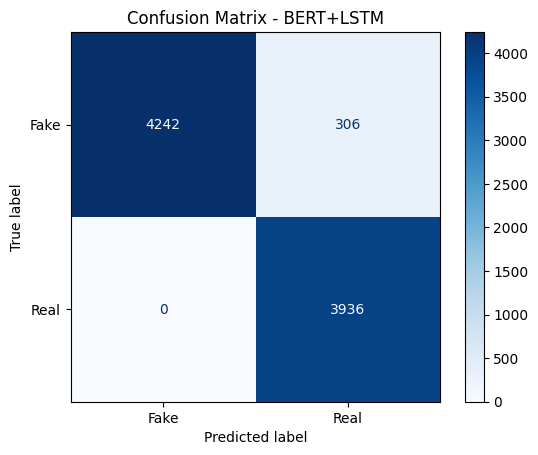

In [ ]:
X_test_input_ids = np.array(X_test_bert["input_ids"])
X_test_attention_mask = np.array(X_test_bert["attention_mask"])
y_test_np = np.array(y_test_BERT)  # Convert labels to numpy array
y_pred_probs = BERT_LSTM.predict({"input_ids": X_test_input_ids, "attention_mask": X_test_attention_mask})
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_np, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - BERT+LSTM")
plt.show()

### Feature Importance Evaluation:

LR SHAP values


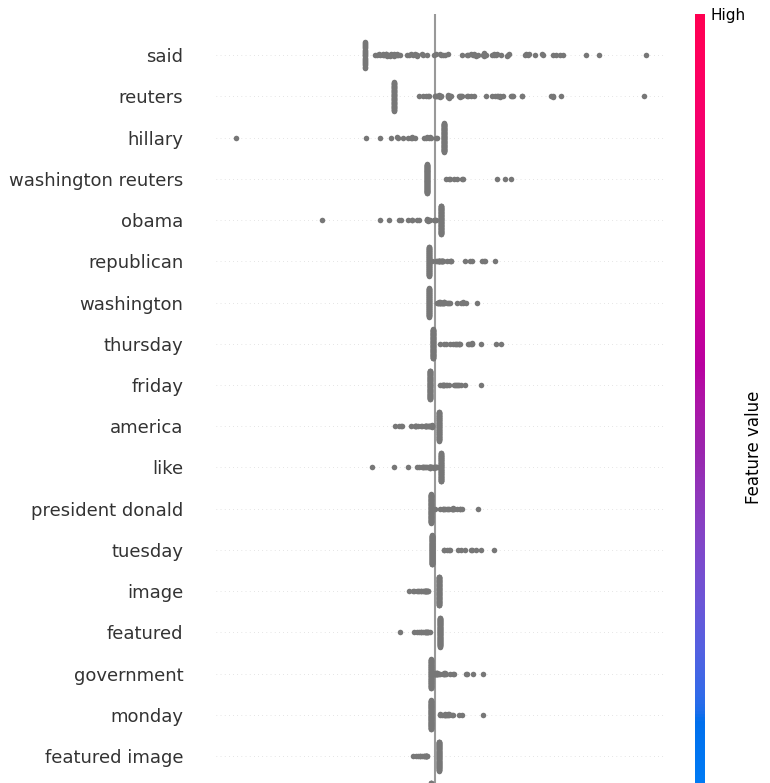

In [ ]:
print("LR SHAP values")
display(Image(filename="LR_SHAP.png"))

NB SHAP values


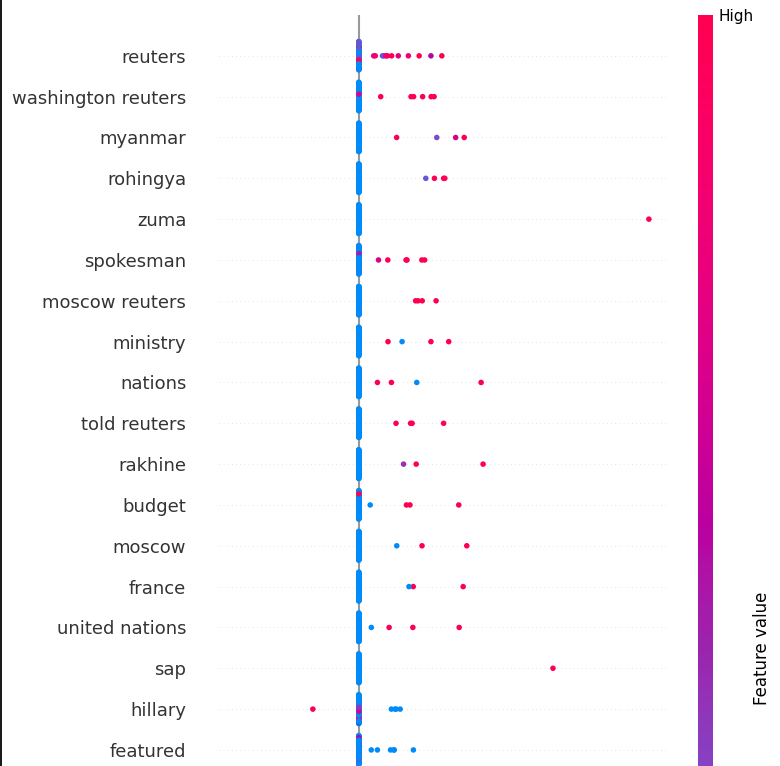

In [ ]:
print("NB SHAP values")
display(Image(filename="NB_SHAP.png"))

SVM SHAP values


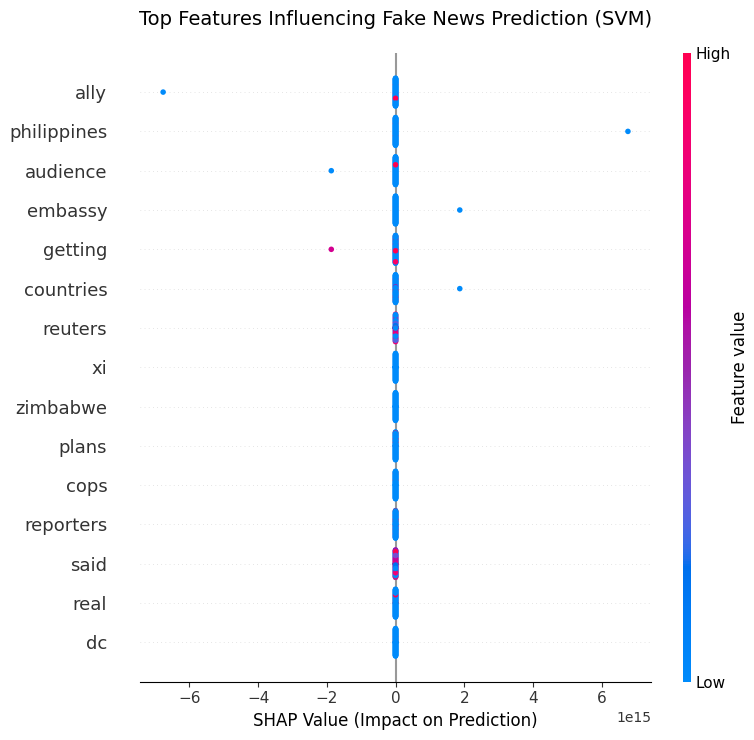

In [ ]:
print("SVM SHAP values")
display(Image(filename="SVM_SHAP.png"))

RF SHAP values


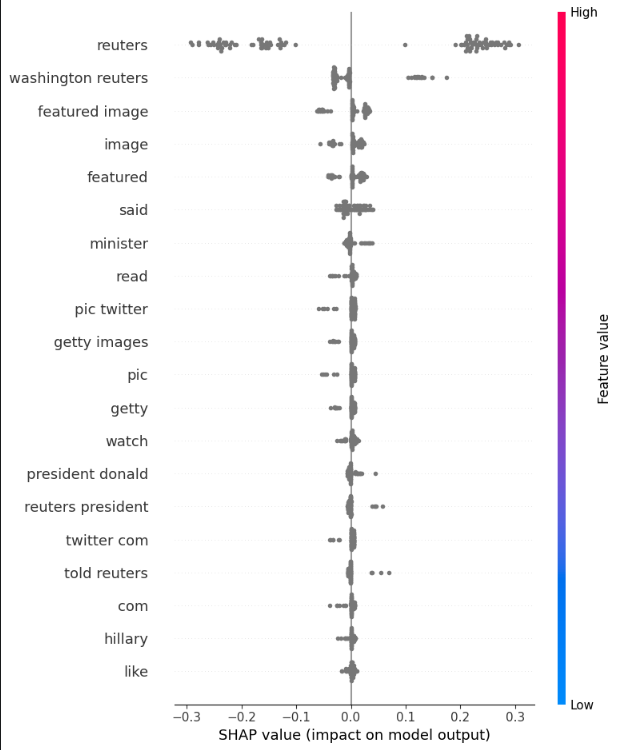

In [ ]:
print("RF SHAP values")
display(Image(filename="RF_SHAP.png"))

In [ ]:
LSTM_LIME = pd.read_csv('LSTM_lime_word_importance.csv')
LSTM_LIME.head(10).T

,0,1,2,3,4,5,6,7,8,9
Word,Trump,that,story,following,you,of,Person,is,now,Tuesday
Importance,-0.000189,-0.000114,0.000111,0.000051,-0.000048,0.000041,-0.000038,-0.000036,-0.000035,-0.000034


In [ ]:
CNN_LSTM_LIME = pd.read_csv('CNN_LSTM_lime_word_importance.csv')
CNN_LSTM_LIME.head(10).T

,0,1,2,3,4,5,6,7,8,9
Word,s,the,Trump,that,said,Obama,Duterte,Mr,pic,Philippines
Importance,0.003292,0.003227,0.002855,0.002765,-0.002593,0.001357,-0.001343,0.001142,0.000929,-0.000926


In [ ]:
BIGRU_LIME = pd.read_csv('BIGRU_lime_word_importance.csv')
BIGRU_LIME.head(10).T

,0,1,2,3,4,5,6,7,8,9
Word,were,No,no,found,outraged,YORK,Obama,when,forced,produce
Importance,12.859249,0.418931,0.350619,0.201453,0.19364,0.185303,0.168688,0.15117,0.099669,0.089113


In [ ]:
BERT_LIME = pd.read_csv('BERT_features.csv')
BERT_LIME.head(10).T

,0,1,2,3,4,5,6,7,8,9
Word,Reuters,money,and,a,s,designed,George,WASHINGTON,YORK,much
Importance,1.158311,1.00414,0.981187,0.940696,0.572972,0.266561,0.25451,0.224593,0.218697,0.21282


In [ ]:
BERT_LSTM_LIME = pd.read_csv('BERT_LSTM_features.csv')
BERT_LSTM_LIME.head(10).T

,0,1,2,3,4,5,6,7,8,9
Word,and,a,is,money,What,level,Reuters,spent,Williams,door
Importance,0.002674,0.002659,0.002406,0.002392,0.002186,0.000876,0.000759,0.000712,0.000624,0.000497


### "Reuters" is conisdered the most importnat feature by BERT, Random Forest, and Naive Bayes

## Common words like "is" and "that" are words the Deep Learning models find unusally important

### Unusual words such as 's' are considered important by certain models

### User Input Evaluation:

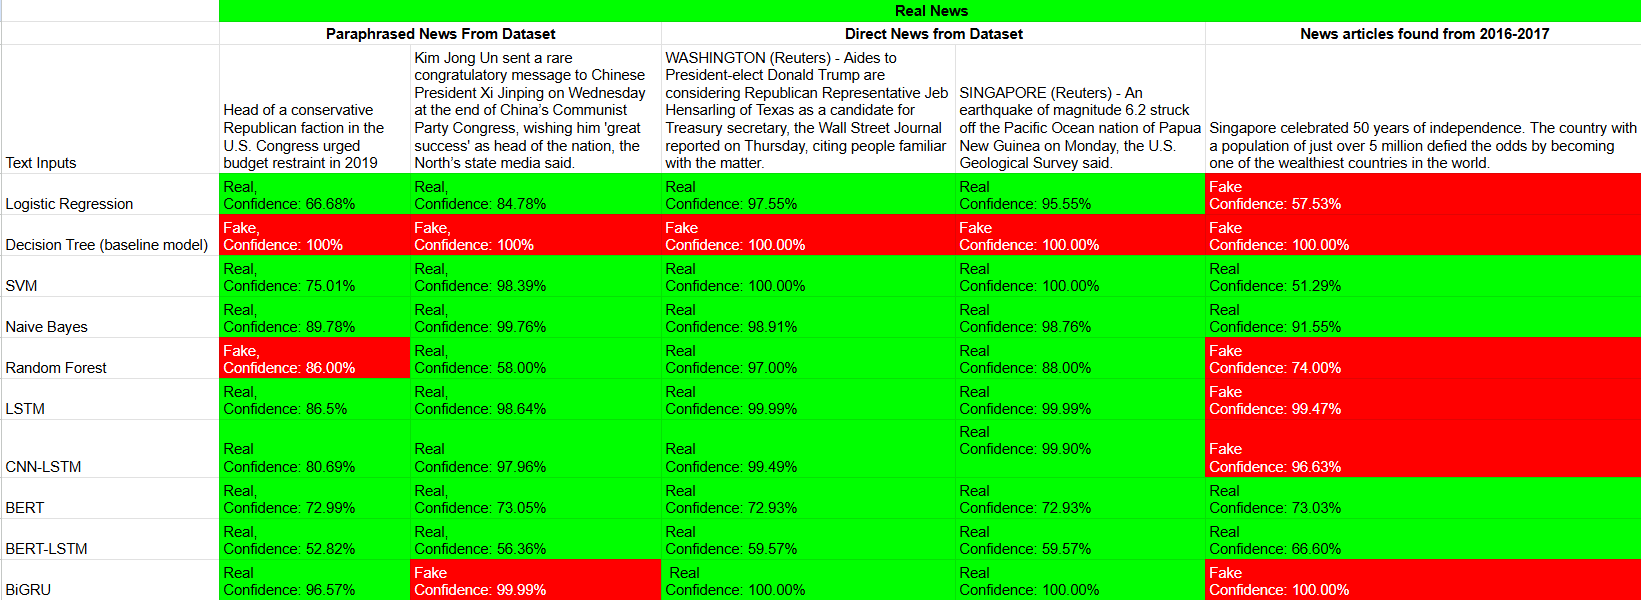

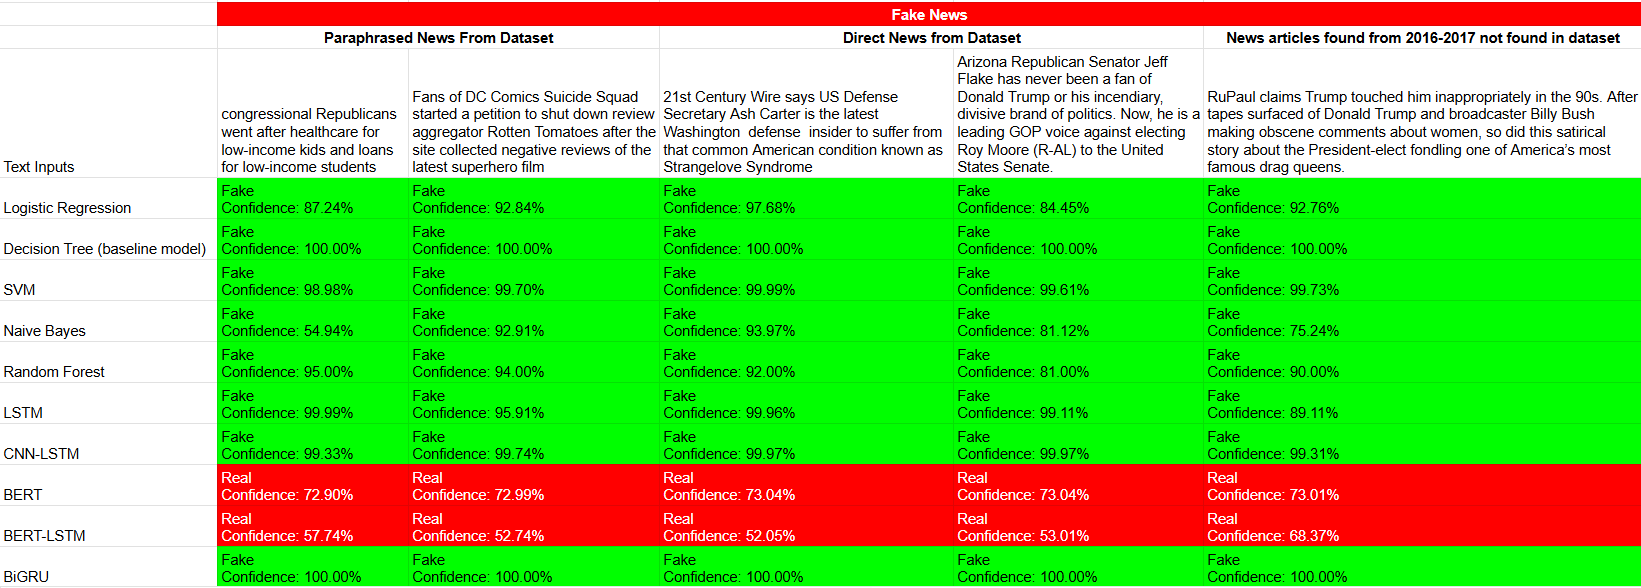

In [133]:
display(Image(filename="UserInputTestTrue.png"))
display(Image(filename="UserInputTestFake.png"))

#### The Decision Tree model was a baseline model used to be compared to the other models. 

### The BERT Models surprisingly failed to identify the Fake news articles correctly. This may mean the models had too little training or that they focused too much in the wrong words to determine their predictions

### SVM and Naive Bayes were the only 2 models to not make any inaccurate predictions